## - Clustering with embedding models -
## - Text-clustering-inspired method of topic modeling, namely BERTopic.

In [1]:
!nvidia-smi

Sun Mar  1 13:50:43 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.126.09             Driver Version: 580.126.09     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          On  |   00000000:04:00.0 Off |                  Off |
| N/A   26C    P0             52W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

#### Clustering with embedding models

#### ArXiv’s Articles: Computation and Language
Throughout this chapter, we will be running clustering and topic modeling algorithms on ArXiv articles. ArXiv is an open-access platform for scholarly articles, mostly in the fields of computer science, mathematics, and physics. We will explore articles in the field of Computation and Language to keep with the theme of this book. The dataset contains 44,949 abstracts between 1991 and 2024 from ArXiv’s cs.CL (Computation and Language) section

###### Clustering
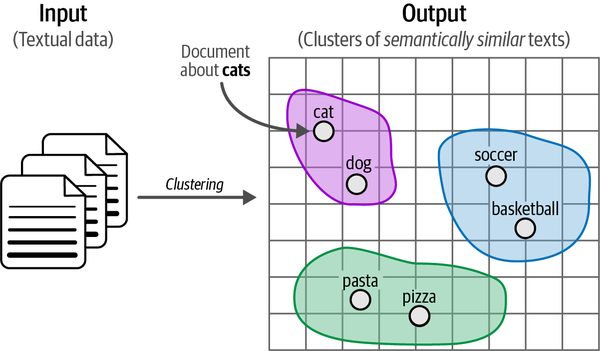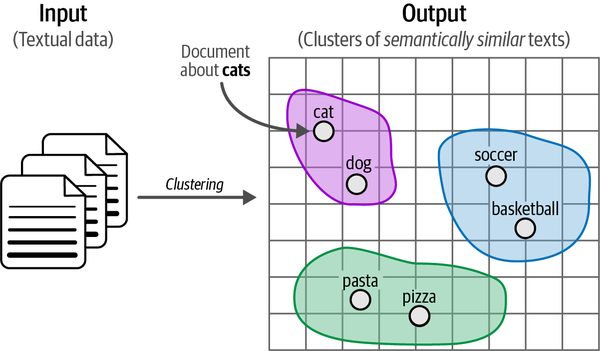

In [2]:
# Load data from Hugging Face
from datasets import load_dataset
dataset = load_dataset("maartengr/arxiv_nlp")["train"]

# Extract metadata
abstracts = dataset["Abstracts"]
titles = dataset["Titles"]

# abstracts = dataset["Abstracts"][:50]
# titles = dataset["Titles"][:50]

In [3]:
len(abstracts)

44949

In [4]:
titles[1],abstracts[1]

('Arabic Speech Recognition System using CMU-Sphinx4',
 '  In this paper we present the creation of an Arabic version of Automated\nSpeech Recognition System (ASR). This system is based on the open source\nSphinx-4, from the Carnegie Mellon University. Which is a speech recognition\nsystem based on discrete hidden Markov models (HMMs). We investigate the\nchanges that must be made to the model to adapt Arabic voice recognition.\n  Keywords: Speech recognition, Acoustic model, Arabic language, HMMs,\nCMUSphinx-4, Artificial intelligence.\n')

###### Choosing the Embedding model
Used the MTEB leaderboard to select an embedding model. We will need an embedding model that has a decent score on clustering tasks but also is small enough to run quickly. Instead of using the “sentence-transformers/all-mpnet-base-v2” model we used in preious notebooks, this time use the “thenlper/gte-small” model instead. It is a more recent model that outperforms the previous model on clustering tasks and due to its small size is even faster for inference.

###### METB leaderboard
https://huggingface.co/spaces/mteb/leaderboard

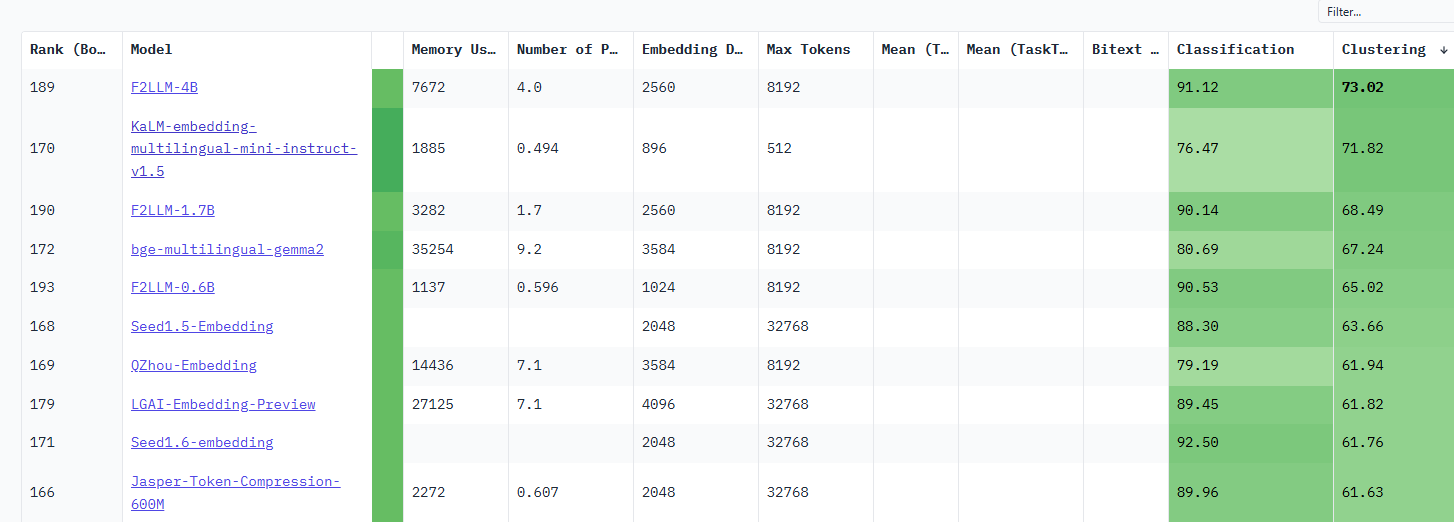

####  GTE Mini vs Small vs Others
https://huggingface.co/thenlper/gte-small
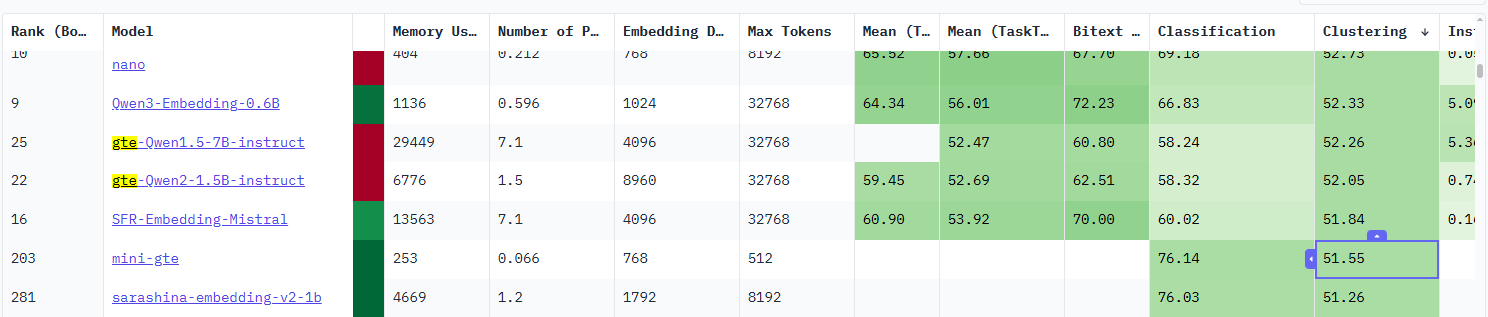

###### Compare
| Model Name                     | Model Size (GB) | Dimension | Sequence Length | Average (56) | Clustering (11) | Pair Classification (3) | Reranking (4) | Retrieval (15) | STS (10) | Summarization (1) | Classification (12) |
|--------------------------------|-----------------|-----------|------------------|--------------|------------------|--------------------------|---------------|----------------|----------|-------------------|---------------------|
| gte-large                      | 0.67            | 1024      | 512              | 63.13        | 46.84            | 85.00                    | 59.13         | 52.22          | 83.35    | 31.66             | 73.33               |
| gte-base                       | 0.22            | 768       | 512              | 62.39        | 46.20            | 84.57                    | 58.61         | 51.14          | 82.30    | 31.17             | 73.01               |
| e5-large-v2                    | 1.34            | 1024      | 512              | 62.25        | 44.49            | 86.03                    | 56.61         | 50.56          | 82.05    | 30.19             | 75.24               |
| e5-base-v2                     | 0.44            | 768       | 512              | 61.50        | 43.80            | 85.73                    | 55.91         | 50.29          | 81.05    | 30.28             | 73.84               |
| gte-small                      | 0.07            | 384       | 512              | 61.36        | 44.89            | 83.54                    | 57.70         | 49.46          | 82.07    | 30.42             | 72.31               |
| text-embedding-ada-002         | –               | 1536      | 8192             | 60.99        | 45.90            | 84.89                    | 56.32         | 49.25          | 80.97    | 30.80             | 70.93               |
| e5-small-v2                    | 0.13            | 384       | 512              | 59.93        | 39.92            | 84.67                    | 54.32         | 49.04          | 80.39    | 31.16             | 72.94               |
| sentence-t5-xxl                | 9.73            | 768       | 512              | 59.51        | 43.72            | 85.06                    | 56.42         | 42.24          | 82.63    | 30.08             | 73.42               |
| all-mpnet-base-v2              | 0.44            | 768       | 514              | 57.78        | 43.69            | 83.04                    | 59.36         | 43.81          | 80.28    | 27.49             | 65.07               |
| sgpt-bloom-7b1-msmarco         | 28.27           | 4096      | 2048             | 57.59        | 38.93            | 81.90                    | 55.65         | 48.22          | 77.74    | 33.60             | 66.19               |
| all-MiniLM-L12-v2              | 0.13            | 384       | 512              | 56.53        | 41.81            | 82.41                    | 58.44         | 42.69          | 79.80    | 27.90             | 63.21               |
| all-MiniLM-L6-v2               | 0.09            | 384       | 512              | 56.26        | 42.35            | 82.37                    | 58.04         | 41.95          | 78.90    | 30.81             | 63.05               |
| contriever-base-msmarco        | 0.44            | 768       | 512              | 56.00        | 41.10            | 82.54                    | 53.14         | 41.88          | 76.51    | 30.36             | 66.68               |
| sentence-t5-base               | 0.22            | 768       | 512              | 55.27        | 40.21            | 85.18                    | 53.09         | 33.63          | 81.14    | 31.39             | 69.81               |

In [3]:
import umap, numba, numpy, pynndescent, sklearn
print(umap.__version__, numba.__version__, numpy.__version__, pynndescent.__version__, sklearn.__version__)

0.5.11 0.61.0 1.26.4 0.6.0 1.6.1


In [14]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [15]:
from sentence_transformers import SentenceTransformer

# Create an embedding for each abstract
embedding_model = SentenceTransformer("thenlper/gte-small")
embeddings = embedding_model.encode(abstracts, show_progress_bar=True)
# Check the dimensions of the resulting embeddings
print(embeddings.shape)

/opt/conda/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batches:   0%|          | 0/1405 [00:00<?, ?it/s]

(44949, 384)


In [16]:
from umap import UMAP

# We reduce the input embeddings from 384 dimensions to 5 dimensions
umap_model = UMAP(
    n_components=5, min_dist=0.0, metric='cosine', random_state=42
)
reduced_embeddings = umap_model.fit_transform(embeddings)

/opt/conda/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [21]:
from hdbscan import HDBSCAN

# We fit the model and extract the clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=50, metric="euclidean", cluster_selection_method="eom"
).fit(reduced_embeddings)
clusters = hdbscan_model.labels_

# How many clusters did we generate?
len(set(clusters))

160

##### How Clusters Look like

In [18]:
import numpy as np

# Print first three documents in cluster 0
cluster = 0
for index in np.where(clusters==cluster)[0][:3]:
    print(abstracts[index][:300] + "... \n")

  This works aims to design a statistical machine translation from English text
to American Sign Language (ASL). The system is based on Moses tool with some
modifications and the results are synthesized through a 3D avatar for
interpretation. First, we translate the input text to gloss, a written fo... 

  Researches on signed languages still strongly dissociate lin- guistic issues
related on phonological and phonetic aspects, and gesture studies for
recognition and synthesis purposes. This paper focuses on the imbrication of
motion and meaning for the analysis, synthesis and evaluation of sign lang... 

  Modern computational linguistic software cannot produce important aspects of
sign language translation. Using some researches we deduce that the majority of
automatic sign language translation systems ignore many aspects when they
generate animation; therefore the interpretation lost the truth inf... 



/opt/conda/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


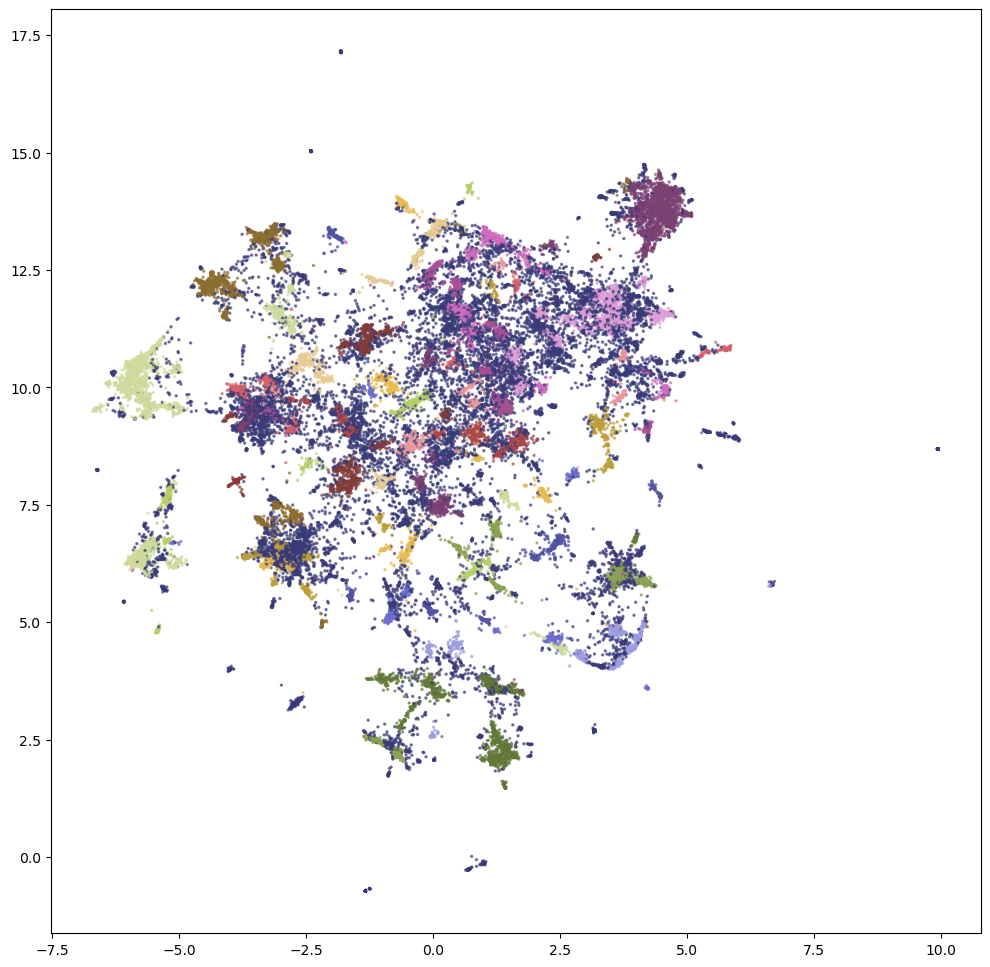

In [19]:
import pandas as pd

# Reduce 384-dimensional embeddings to two dimensions for easier visualization
reduced_embeddings = UMAP(
    n_components=2, min_dist=0.0, metric="cosine", random_state=42
).fit_transform(embeddings)

# Create dataframe
df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
df["title"] = titles
df["cluster"] = [str(c) for c in clusters]

# Select outliers and non-outliers (clusters)
to_plot = df.loc[df.cluster != "-1", :]
outliers = df.loc[df.cluster == "-1", :]


import matplotlib.pyplot as plt

# Plot outliers and non-outliers separately
plt.figure(figsize=(12, 12))
plt.scatter(outliers.x, outliers.y, alpha=0.05, s=2, c="grey")
plt.scatter(
    df.x, df.y, c=df.cluster.astype(int),
    alpha=0.6, s=2, cmap="tab20b"
)
# plt.axis("off")

## Use Diff Model for Clustering

In [23]:
from sentence_transformers import SentenceTransformer

# Create an embedding for each abstract
embedding_model = SentenceTransformer("prdev/mini-gte")
embeddings = embedding_model.encode(abstracts, show_progress_bar=True)
# Check the dimensions of the resulting embeddings
print(embeddings.shape)

/opt/conda/lib/python3.12/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Batches:   0%|          | 0/1405 [00:00<?, ?it/s]

(44949, 768)


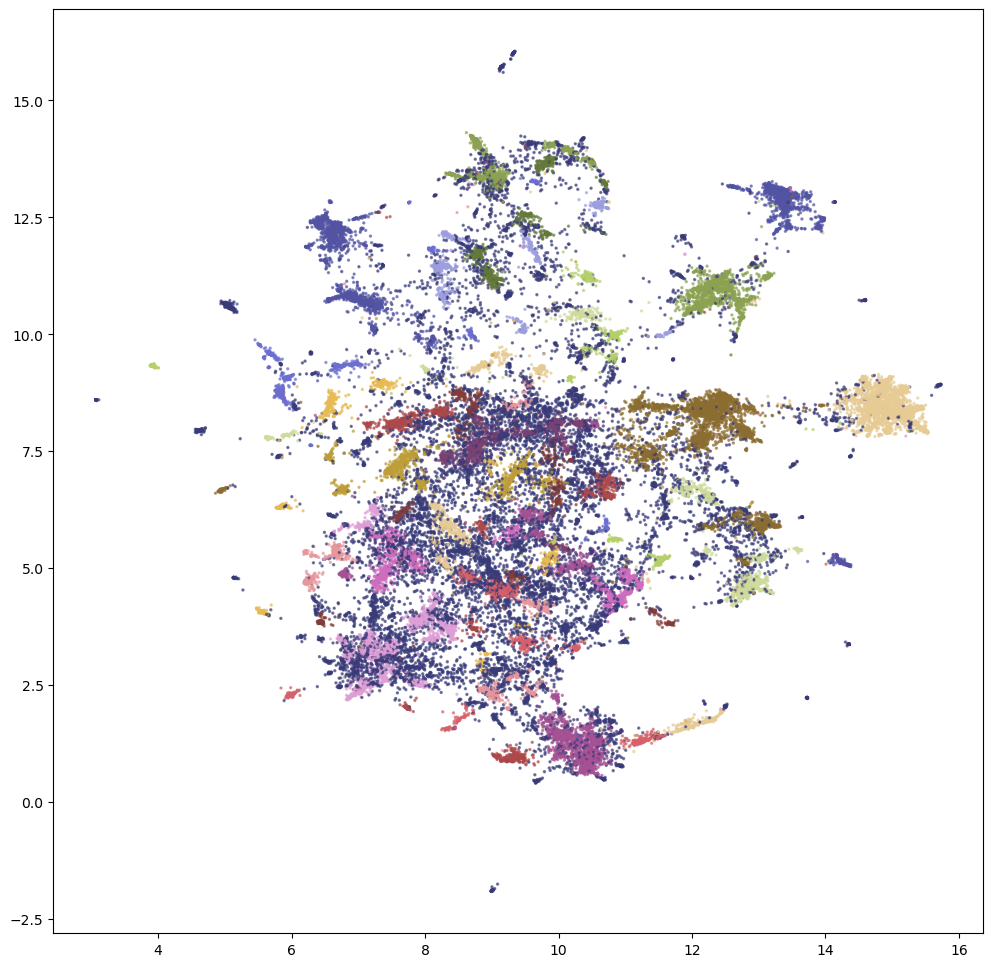

In [26]:
from umap import UMAP

# We reduce the input embeddings from 384 dimensions to 5 dimensions
umap_model = UMAP(
    n_components=5, min_dist=0.0, metric='cosine', random_state=42
)
reduced_embeddings = umap_model.fit_transform(embeddings)

from hdbscan import HDBSCAN

# We fit the model and extract the clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=50, metric="euclidean", cluster_selection_method="eom"
).fit(reduced_embeddings)
clusters = hdbscan_model.labels_

# How many clusters did we generate?
print("Total Clusters:", len(set(clusters)))

import pandas as pd

# Reduce 384-dimensional embeddings to two dimensions for easier visualization
reduced_embeddings = UMAP(
    n_components=2, min_dist=0.0, metric="cosine", random_state=42
).fit_transform(embeddings)

# Create dataframe
df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
df["title"] = titles
df["cluster"] = [str(c) for c in clusters]

# Select outliers and non-outliers (clusters)
to_plot = df.loc[df.cluster != "-1", :]
outliers = df.loc[df.cluster == "-1", :]


import matplotlib.pyplot as plt
# Set figure size to 12x12 inches
plt.figure(figsize=(12, 12))

# Plot outliers and non-outliers separately
plt.scatter(outliers.x, outliers.y, alpha=0.05, s=2, c="grey")
plt.scatter(
    df.x, df.y, c=df.cluster.astype(int),
    alpha=0.6, s=2, cmap="tab20b"
)
# plt.axis("off")